In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

In [15]:
train = pd.read_csv("fraudTrain.csv")
test = pd.read_csv("fraudTest.csv")

In [17]:
df.shape
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  str    
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  str    
 4   category               1296675 non-null  str    
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  str    
 7   last                   1296675 non-null  str    
 8   gender                 1296675 non-null  str    
 9   street                 1296675 non-null  str    
 10  city                   1296675 non-null  str    
 11  state                  1296675 non-null  str    
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long                   129667

,Unnamed: 0,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06
mean,6.483370e+05,4.171920e+17,7.035104e+01,4.880067e+04,3.853762e+01,-9.022634e+01,8.882444e+04,1.349244e+09,3.853734e+01,-9.022646e+01,5.788652e-03
std,3.743180e+05,1.308806e+18,1.603160e+02,2.689322e+04,5.075808e+00,1.375908e+01,3.019564e+05,1.284128e+07,5.109788e+00,1.377109e+01,7.586269e-02
min,0.000000e+00,6.041621e+10,1.000000e+00,1.257000e+03,2.002710e+01,-1.656723e+02,2.300000e+01,1.325376e+09,1.902779e+01,-1.666712e+02,0.000000e+00
25%,3.241685e+05,1.800429e+14,9.650000e+00,2.623700e+04,3.462050e+01,-9.679800e+01,7.430000e+02,1.338751e+09,3.473357e+01,-9.689728e+01,0.000000e+00
50%,6.483370e+05,3.521417e+15,4.752000e+01,4.817400e+04,3.935430e+01,-8.747690e+01,2.456000e+03,1.349250e+09,3.936568e+01,-8.743839e+01,0.000000e+00
75%,9.725055e+05,4.642255e+15,8.314000e+01,7.204200e+04,4.194040e+01,-8.015800e+01,2.032800e+04,1.359385e+09,4.195716e+01,-8.023680e+01,0.000000e+00
max,1.296674e+06,4.992346e+18,2.894890e+04,9.978300e+04,6.669330e+01,-6.795030e+01,2.906700e+06,1.371817e+09,6.751027e+01,-6.695090e+01,1.000000e+00


In [13]:
summary = pd.DataFrame({
    'Column': df.columns,
    'Data Type': df.dtypes,
    'Non-Null Count': df.notnull().sum(),
    'Missing Values': df.isnull().sum()
})

summary

,Column,Data Type,Non-Null Count,Missing Values
Unnamed: 0,Unnamed: 0,int64,1296675,0
trans_date_trans_time,trans_date_trans_time,str,1296675,0
cc_num,cc_num,int64,1296675,0
merchant,merchant,str,1296675,0
category,category,str,1296675,0
amt,amt,float64,1296675,0
first,first,str,1296675,0
last,last,str,1296675,0
gender,gender,str,1296675,0
street,street,str,1296675,0


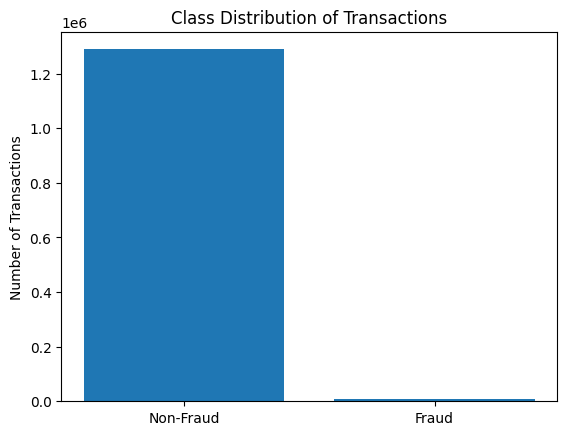

In [8]:
labels = ['Non-Fraud', 'Fraud']
counts = train['is_fraud'].value_counts()

plt.figure()
plt.bar(labels, counts)
plt.title("Class Distribution of Transactions")
plt.ylabel("Number of Transactions")
plt.show()

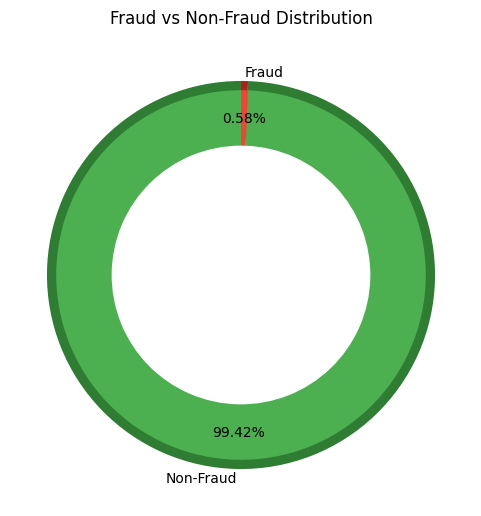

In [10]:
import matplotlib.pyplot as plt

fraud_counts = df['is_fraud'].value_counts()

labels = ['Non-Fraud', 'Fraud']
sizes = fraud_counts.values
colors = ['#4CAF50', '#F44336']  # hijau vs merah

fig, ax = plt.subplots(figsize=(6,6))

# layer bawah (shadow / depth)
ax.pie(
    sizes,
    radius=1.05,
    colors=['#2e7d32', '#b71c1c'],  # warna lebih gelap
    startangle=90,
    wedgeprops=dict(width=0.3)
)

# layer atas (main donut)
wedges, texts, autotexts = ax.pie(
    sizes,
    labels=labels,
    autopct='%1.2f%%',
    startangle=90,
    colors=colors,
    wedgeprops=dict(width=0.3),
    pctdistance=0.85
)

# biar bentuknya bulat
ax.set(aspect="equal")

plt.title('Fraud vs Non-Fraud Distribution', pad=15)
plt.show()

In [18]:
train['trans_date_trans_time'] = pd.to_datetime(train['trans_date_trans_time'])
test['trans_date_trans_time'] = pd.to_datetime(test['trans_date_trans_time'])

train['hour'] = train['trans_date_trans_time'].dt.hour
test['hour'] = test['trans_date_trans_time'].dt.hour

train['is_weekend'] = train['trans_date_trans_time'].dt.dayofweek >= 5
test['is_weekend'] = test['trans_date_trans_time'].dt.dayofweek >= 5

In [19]:
fraud = train[train['is_fraud'] == 1]
non_fraud = train[train['is_fraud'] == 0].sample(len(fraud)*3, random_state=42)

train_balanced = pd.concat([fraud, non_fraud])


In [20]:
features = ['amt', 'lat', 'long', 'city_pop', 'unix_time', 'hour', 'is_weekend']

X_train = train_balanced[features]
y_train = train_balanced['is_fraud']

X_test = test[features]
y_test = test['is_fraud']

In [21]:
model = RandomForestClassifier(n_estimators=50, random_state=42)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",50
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

In [22]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:,1]

In [23]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       1.00      0.98      0.99    553574
           1       0.12      0.81      0.20      2145

    accuracy                           0.98    555719
   macro avg       0.56      0.89      0.60    555719
weighted avg       1.00      0.98      0.98    555719



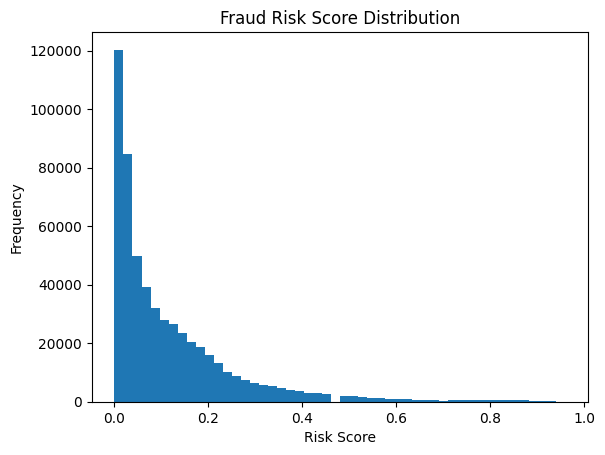

In [25]:
plt.figure()
plt.hist(y_proba, bins=50)
plt.title("Fraud Risk Score Distribution")
plt.xlabel("Risk Score")
plt.ylabel("Frequency")
plt.show()

In [26]:
def risk_level(score):
    if score > 0.8:
        return "High"
    elif score > 0.5:
        return "Medium"
    else:
        return "Low"

sample_scores = y_proba[:10]
risk_labels = [risk_level(s) for s in sample_scores]

print(risk_labels)


['Low', 'Low', 'Low', 'Low', 'Low', 'Low', 'Low', 'Low', 'Low', 'Low']


In [27]:
sample_idx = np.random.choice(len(y_proba), 10, replace=False)
sample_scores = y_proba[sample_idx]

risk_labels = [risk_level(s) for s in sample_scores]

print(sample_scores)
print(risk_labels)

[0.4  0.   0.06 0.28 0.04 0.1  0.18 0.06 0.06 0.  ]
['Low', 'Low', 'Low', 'Low', 'Low', 'Low', 'Low', 'Low', 'Low', 'Low']


In [28]:
train['amt_log'] = np.log1p(train['amt'])
test['amt_log'] = np.log1p(test['amt'])

In [29]:
train['trans_count'] = train.groupby('cc_num')['amt'].transform('count')
test['trans_count'] = test.groupby('cc_num')['amt'].transform('count')

In [30]:
features = [
    'amt', 'amt_log',
    'lat', 'long',
    'city_pop',
    'unix_time',
    'hour', 'is_weekend',
    'trans_count'
]

In [31]:
from sklearn.ensemble import GradientBoostingClassifier

model = GradientBoostingClassifier()
model.fit(X_train, y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

In [32]:
threshold = 0.3
y_pred_custom = (y_proba > threshold).astype(int)

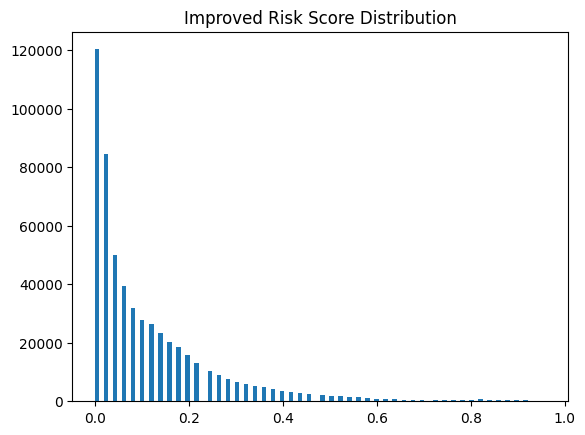

In [33]:
plt.figure()
plt.hist(y_proba, bins=100)
plt.title("Improved Risk Score Distribution")
plt.show()

In [34]:
def risk_level(score):
    if score > 0.8:
        return "High"
    elif score > 0.5:
        return "Medium"
    else:
        return "Low"

sample_scores = y_pred_custom[:10]

sample_idx = np.random.choice(len(y_pred_custom), 10, replace=False)
sample_scores = y_pred_custom[sample_idx]

risk_labels = [risk_level(s) for s in sample_scores]

print(sample_scores)
print(risk_labels)

[0 0 0 0 0 1 0 0 1 0]
['Low', 'Low', 'Low', 'Low', 'Low', 'High', 'Low', 'Low', 'High', 'Low']


In [35]:
sample_idx = np.random.choice(len(y_proba), 10, replace=False)
sample_scores = y_proba[sample_idx]

risk_labels = [risk_level(s) for s in sample_scores]

print(sample_scores)
print(risk_labels)

[0.04 0.22 0.42 0.12 0.   0.   0.06 0.   0.08 0.2 ]
['Low', 'Low', 'Low', 'Low', 'Low', 'Low', 'Low', 'Low', 'Low', 'Low']


In [36]:
print(sum(y_test == 1))

2145


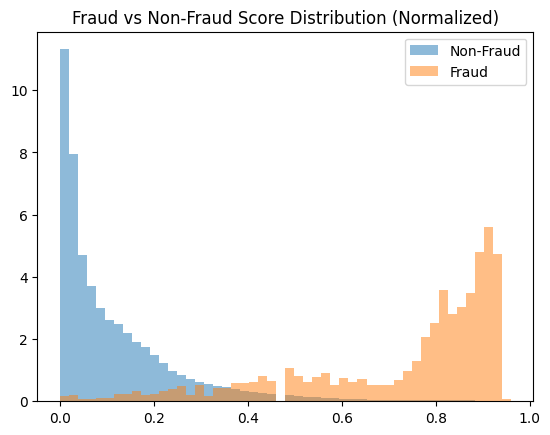

In [37]:
#NORMALISASI

plt.figure()

plt.hist(y_proba[y_test == 0], bins=50, alpha=0.5, label='Non-Fraud', density=True)
plt.hist(y_proba[y_test == 1], bins=50, alpha=0.5, label='Fraud', density=True)

plt.legend()
plt.title("Fraud vs Non-Fraud Score Distribution (Normalized)")
plt.show()

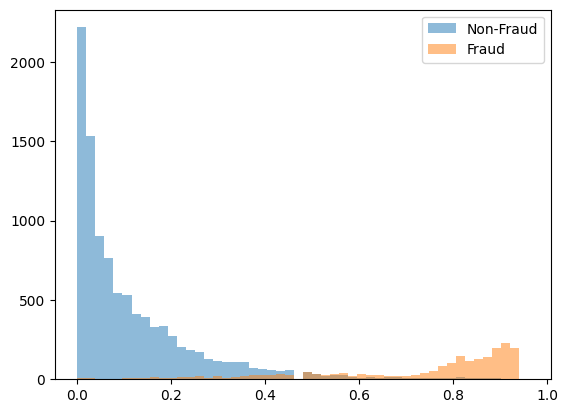

In [ ]:
#SAMPLE AJA

non_fraud_sample = y_proba[y_test == 0][:10000]
fraud_sample = y_proba[y_test == 1]

plt.figure()
plt.hist(non_fraud_sample, bins=50, alpha=0.5, label='Non-Fraud')
plt.hist(fraud_sample, bins=50, alpha=0.5, label='Fraud')

plt.legend()
plt.show()

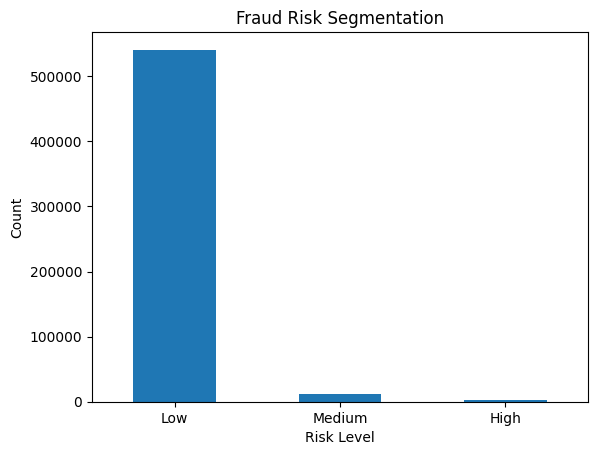

In [39]:
def risk_level(score):
    if score > 0.8:
        return "High"
    elif score > 0.5:
        return "Medium"
    else:
        return "Low"

risk_labels = pd.Series(y_proba).apply(risk_level)

risk_counts = risk_labels.value_counts()

risk_counts.plot(kind='bar')
plt.title('Fraud Risk Segmentation')
plt.xlabel('Risk Level')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

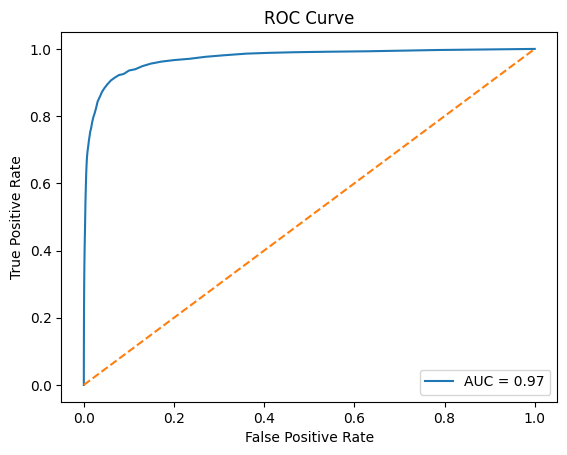

In [41]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

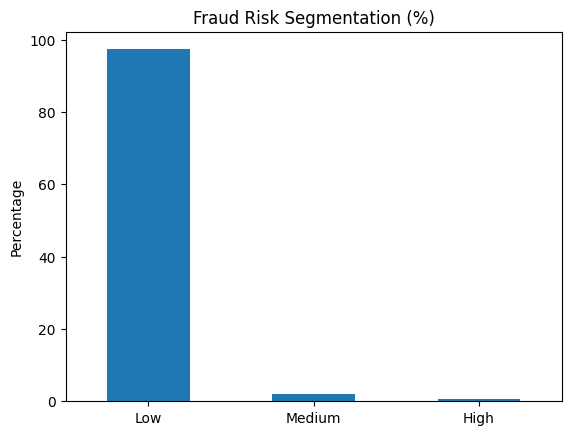

Low       97.320408
Medium     2.116897
High       0.562694
Name: proportion, dtype: float64


In [42]:
import pandas as pd
import matplotlib.pyplot as plt

def risk_level(score):
    if score > 0.8:
        return "High"
    elif score > 0.5:
        return "Medium"
    else:
        return "Low"

risk_labels = pd.Series(y_proba).apply(risk_level)

risk_dist = risk_labels.value_counts(normalize=True) * 100

risk_dist = risk_dist[['Low','Medium','High']]

risk_dist.plot(kind='bar')
plt.title('Fraud Risk Segmentation (%)')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.show()

print(risk_dist)

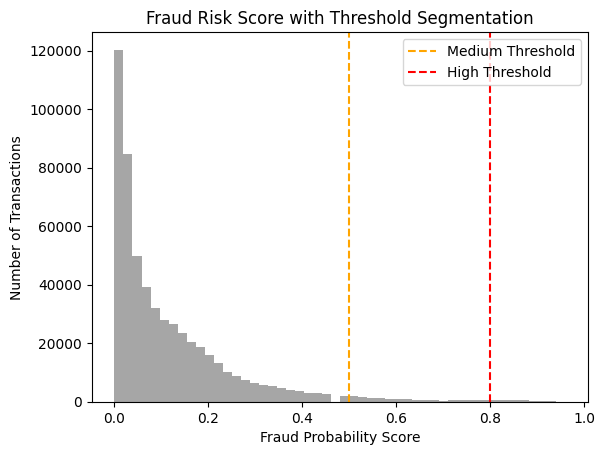

In [47]:
plt.figure()

plt.hist(y_proba, bins=50, alpha=0.7, color='gray')

plt.axvline(0.5, color='orange', linestyle='--', label='Medium Threshold')
plt.axvline(0.8, color='red', linestyle='--', label='High Threshold')

plt.title("Fraud Risk Score with Threshold Segmentation")
plt.xlabel("Fraud Probability Score")
plt.ylabel("Number of Transactions")

plt.legend()
plt.show()

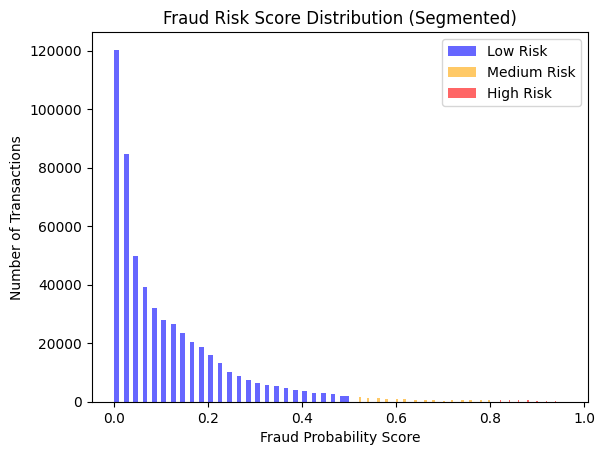

In [48]:
plt.figure()

low = y_proba[y_proba <= 0.5]
medium = y_proba[(y_proba > 0.5) & (y_proba <= 0.8)]
high = y_proba[y_proba > 0.8]

plt.hist(low, bins=50, alpha=0.6, label='Low Risk', color='blue')
plt.hist(medium, bins=50, alpha=0.6, label='Medium Risk', color='orange')
plt.hist(high, bins=50, alpha=0.6, label='High Risk', color='red')

plt.title("Fraud Risk Score Distribution (Segmented)")
plt.xlabel("Fraud Probability Score")
plt.ylabel("Number of Transactions")

plt.legend()
plt.show()